# MRR Analysis — Tidemill API vs Stripe

Compare Monthly Recurring Revenue computed by the Tidemill engine with raw Stripe data.

**API base:** `http://localhost:8000` (after `make check-e2e`) or set `TIDEMILL_API` env var  
**Auth:** Set `TIDEMILL_API_KEY` to a valid API key (`tk_...`), or disable auth with `AUTH_ENABLED=false`  
**Stripe mode:** Test (sandbox)

In [12]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import requests
import stripe

warnings.filterwarnings("ignore", "Unverified HTTPS")

API = os.environ.get("TIDEMILL_API", "http://localhost:8000")
API_KEY = os.environ.get("TIDEMILL_API_KEY", "")
stripe.api_key = os.environ["STRIPE_API_KEY"]

START, END = "2025-09-01", "2026-04-30"

plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})

_session = requests.Session()
if API_KEY:
    _session.headers["Authorization"] = f"Bearer {API_KEY}"


def api_get(path, **params):
    r = _session.get(f"{API}{path}", params=params)
    r.raise_for_status()
    return r.json()

## 1. Current MRR & ARR from Tidemill API

In [13]:
mrr_current = api_get("/api/metrics/mrr", at="2026-03-01")
arr_current = api_get("/api/metrics/arr", at="2026-03-01")

print(f"MRR (Tidemill):  ${mrr_current / 100:,.2f}")
print(f"ARR (Tidemill):  ${arr_current / 100:,.2f}")
print(f"ARR check:       ${mrr_current * 12 / 100:,.2f}  (MRR x 12)")

MRR (Tidemill):  $1,009.33
ARR (Tidemill):  $12,111.96
ARR check:       $12,111.96  (MRR x 12)


## 2. MRR from Stripe (ground truth)

Compute MRR directly from active Stripe subscriptions across all test clocks for comparison.

In [14]:
def stripe_mrr_for_sub(sub):
    """Compute monthly MRR in cents from a Stripe subscription."""
    total = 0
    for item in sub["items"]["data"]:
        price = item["price"]
        qty = item.get("quantity", 1) or 1
        unit_amount = price.get("unit_amount", 0) or 0
        amount = unit_amount * qty
        rec = price.get("recurring") or {}
        interval = rec.get("interval", "month")
        interval_count = rec.get("interval_count", 1) or 1
        if interval == "month":
            total += amount // interval_count
        elif interval == "year":
            total += amount // (12 * interval_count)
        elif interval == "week":
            total += int(amount * 52 / (12 * interval_count))
    return total


# Collect all subscriptions across test clocks
clock_ids = [c.id for c in stripe.test_helpers.TestClock.list(limit=100).auto_paging_iter()]
stripe_subs = []
for cid in clock_ids:
    for sub in stripe.Subscription.list(
        limit=100, test_clock=cid, status="all"
    ).auto_paging_iter():
        stripe_subs.append(sub.to_dict())

df_stripe = pd.DataFrame(
    [
        {
            "id": s["id"],
            "customer": s["customer"],
            "status": s["status"],
            "mrr_cents": stripe_mrr_for_sub(s),
            "currency": s.get("currency", "usd"),
        }
        for s in stripe_subs
    ]
)

print(f"Stripe subscriptions: {len(df_stripe)}")
print(f"  Active:   {(df_stripe.status == 'active').sum()}")
print(f"  Canceled: {(df_stripe.status == 'canceled').sum()}")
print(f"  Trialing: {(df_stripe.status == 'trialing').sum()}")
print()

stripe_mrr = df_stripe[df_stripe.status == "active"].mrr_cents.sum()
print(f"MRR (Stripe):    ${stripe_mrr / 100:,.2f}")
print(f"MRR (Tidemill):  ${mrr_current / 100:,.2f}")
diff = mrr_current - stripe_mrr
print(f"Difference:      ${diff / 100:,.2f}  ({'match!' if diff == 0 else 'see breakdown below'})")

Stripe subscriptions: 38
  Active:   26
  Canceled: 11
  Trialing: 0

MRR (Stripe):    $1,009.33
MRR (Tidemill):  $1,009.33
Difference:      $0.00  (match!)


## 3. Per-subscription MRR comparison

In [15]:
# Side-by-side: Stripe MRR per subscription vs what Tidemill recorded
df_compare = df_stripe[["id", "status", "mrr_cents"]].rename(
    columns={"mrr_cents": "stripe_mrr_cents"}
)
df_compare["stripe_mrr"] = df_compare.stripe_mrr_cents.apply(lambda c: f"${c / 100:,.2f}")
df_compare = df_compare.sort_values("stripe_mrr_cents", ascending=False).reset_index(drop=True)
df_compare

,id,status,stripe_mrr_cents,stripe_mrr
0,sub_1TLTmNCMLOTbZAd7QIgUVBba,active,20750,$207.50
1,sub_1TLTmaCMLOTbZAd7uAxWFKqh,canceled,7900,$79.00
2,sub_1TLTm5CMLOTbZAd787F67ssP,active,7900,$79.00
3,sub_1TLTmACMLOTbZAd7T5dHdvuO,active,7900,$79.00
4,sub_1TLTmfCMLOTbZAd798D9LJgC,active,7900,$79.00
5,sub_1TLTmkCMLOTbZAd7nbo5Vpvd,active,7900,$79.00
6,sub_1TLTmHCMLOTbZAd7f2xktOz8,active,6583,$65.83
7,sub_1TLTmvCMLOTbZAd7Fwe23xy7,incomplete_expired,2100,$21.00
8,sub_1TLTnCCMLOTbZAd7XYmuYyLe,active,2100,$21.00
9,sub_1TLTn8CMLOTbZAd7mDK6NGQC,active,2100,$21.00


## 4. MRR Breakdown (movements)

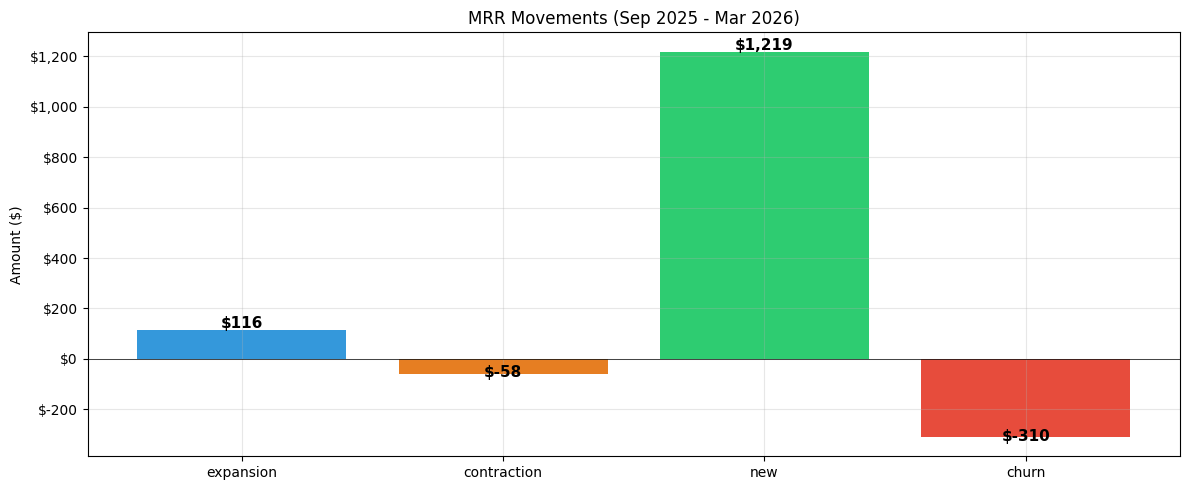


Net MRR change: $967.33


In [16]:
breakdown = api_get("/api/metrics/mrr/breakdown", start=START, end=END)
df_bd = pd.DataFrame(breakdown)
df_bd["amount"] = df_bd["amount_base"] / 100

colors = {"new": "#2ecc71", "expansion": "#3498db", "contraction": "#e67e22", "churn": "#e74c3c"}

fig, ax = plt.subplots()
bars = ax.bar(
    df_bd.movement_type,
    df_bd.amount,
    color=[colors.get(t, "#95a5a6") for t in df_bd.movement_type],
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("MRR Movements (Sep 2025 - Mar 2026)")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

for bar, val in zip(bars, df_bd.amount, strict=True):
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + (5 if y >= 0 else -15),
        f"${val:,.0f}",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

print("\nNet MRR change:", f"${df_bd.amount.sum():,.2f}")

## 5. Monthly MRR with movement split

Query MRR breakdown per month to show how new, expansion, contraction, and churn compose each month's MRR change.

In [17]:
# Monthly MRR waterfall from a single API call
waterfall = api_get("/api/metrics/mrr/waterfall", start=START, end=END)
df_monthly = pd.DataFrame(waterfall)

# Convert cents to dollars
for col in [
    "starting_mrr",
    "new",
    "expansion",
    "contraction",
    "churn",
    "reactivation",
    "net_change",
    "ending_mrr",
]:
    df_monthly[col] = df_monthly[col] / 100

# Display formatted table
display_cols = [
    "starting_mrr",
    "new",
    "expansion",
    "reactivation",
    "contraction",
    "churn",
    "net_change",
    "ending_mrr",
]
fmt = df_monthly.set_index("month")[display_cols]
for c in fmt.columns:
    fmt[c] = fmt[c].apply(lambda x: f"${x:,.2f}")
print("Monthly MRR waterfall:")
print(fmt.to_string())

Monthly MRR waterfall:
        starting_mrr      new expansion reactivation contraction     churn net_change ending_mrr
month                                                                                           
2025-09        $0.00  $715.33     $0.00        $0.00       $0.00   $-42.00    $673.33    $673.33
2025-10      $673.33  $231.00   $116.00        $0.00     $-58.00   $-42.00    $247.00    $920.33
2025-11      $920.33    $0.00     $0.00        $0.00       $0.00  $-121.00   $-121.00    $799.33
2025-12      $799.33  $168.00     $0.00        $0.00       $0.00   $-42.00    $126.00    $925.33
2026-01      $925.33  $105.00     $0.00        $0.00       $0.00   $-21.00     $84.00  $1,009.33
2026-02    $1,009.33    $0.00     $0.00        $0.00       $0.00   $-42.00    $-42.00    $967.33
2026-03      $967.33    $0.00     $0.00        $0.00       $0.00     $0.00      $0.00    $967.33
2026-04      $967.33    $0.00     $0.00        $0.00       $0.00     $0.00      $0.00    $967.33


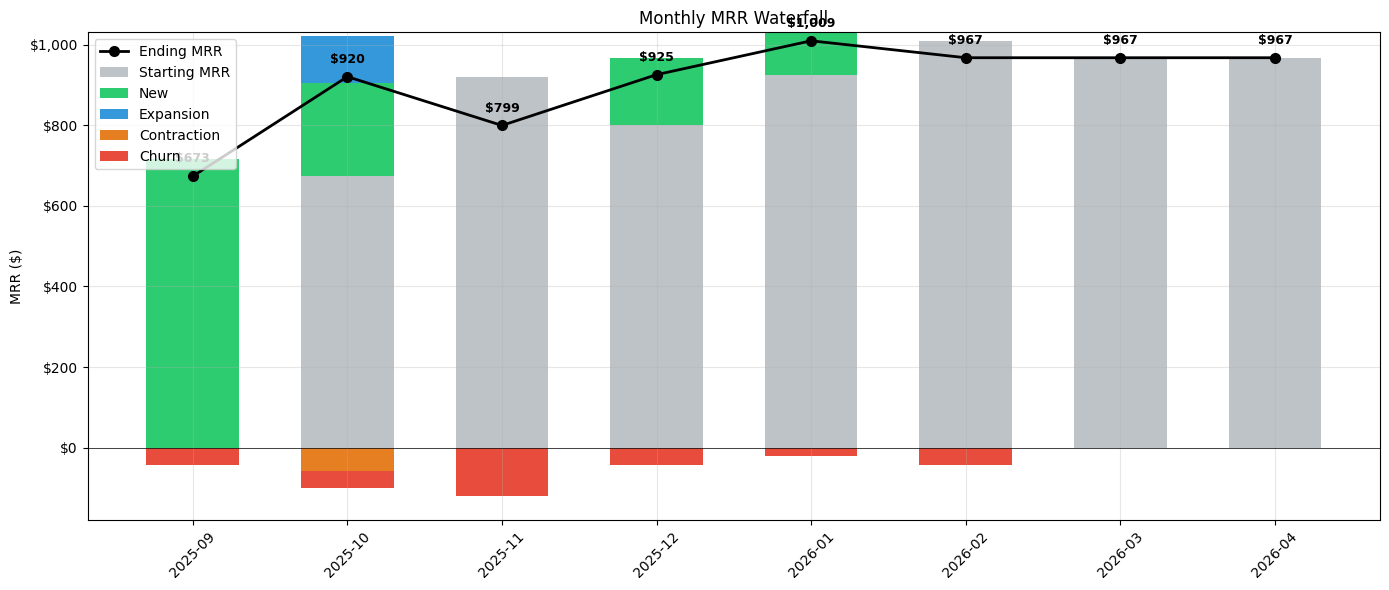

In [18]:
# Stacked bar chart: monthly MRR waterfall
if len(df_monthly) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    dm = df_monthly.set_index("month")

    x = range(len(dm))
    w = 0.6

    colors = {
        "starting_mrr": "#bdc3c7",
        "new": "#2ecc71",
        "expansion": "#3498db",
        "reactivation": "#9b59b6",
        "contraction": "#e67e22",
        "churn": "#e74c3c",
    }

    # Starting MRR as base
    ax.bar(x, dm.starting_mrr, w, label="Starting MRR", color=colors["starting_mrr"])

    # Stack positives upward from starting_mrr
    bottom_pos = dm.starting_mrr.values.copy()
    for col in ["new", "expansion", "reactivation"]:
        vals = dm[col].values
        if vals.any():
            ax.bar(x, vals, w, bottom=bottom_pos, label=col.title(), color=colors[col])
            bottom_pos = bottom_pos + vals

    # Negatives hang below zero
    bottom_neg = 0
    for col in ["contraction", "churn"]:
        vals = dm[col].values  # already negative
        if vals.any():
            ax.bar(x, vals, w, bottom=bottom_neg, label=col.title(), color=colors[col])
            bottom_neg = bottom_neg + vals

    # Ending MRR line
    ax.plot(x, dm.ending_mrr, "ko-", linewidth=2, markersize=7, label="Ending MRR", zorder=5)
    for i, v in enumerate(dm.ending_mrr):
        ax.annotate(
            f"${v:,.0f}",
            (i, v),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontweight="bold",
            fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(dm.index, rotation=45)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Monthly MRR Waterfall")
    ax.set_ylabel("MRR ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

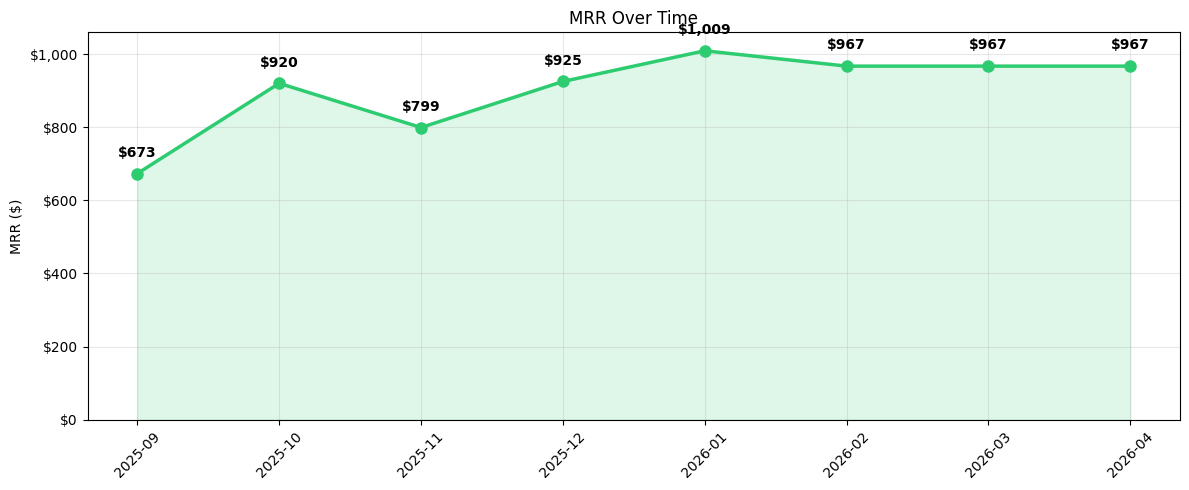

In [19]:
# MRR trend line
if len(df_monthly) > 0:
    dm = df_monthly.set_index("month")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(range(len(dm)), dm.ending_mrr.values, alpha=0.15, color="#2ecc71")
    ax.plot(
        range(len(dm)),
        dm.ending_mrr.values,
        "o-",
        color="#2ecc71",
        linewidth=2.5,
        markersize=8,
    )

    for i, v in enumerate(dm.ending_mrr):
        ax.annotate(
            f"${v:,.0f}",
            (i, v),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontweight="bold",
        )

    ax.set_xticks(range(len(dm)))
    ax.set_xticklabels(dm.index, rotation=45)
    ax.set_title("MRR Over Time")
    ax.set_ylabel("MRR ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

## 6. MRR by subscription status (Stripe vs Tidemill)

Connected sources: ['Stripe']



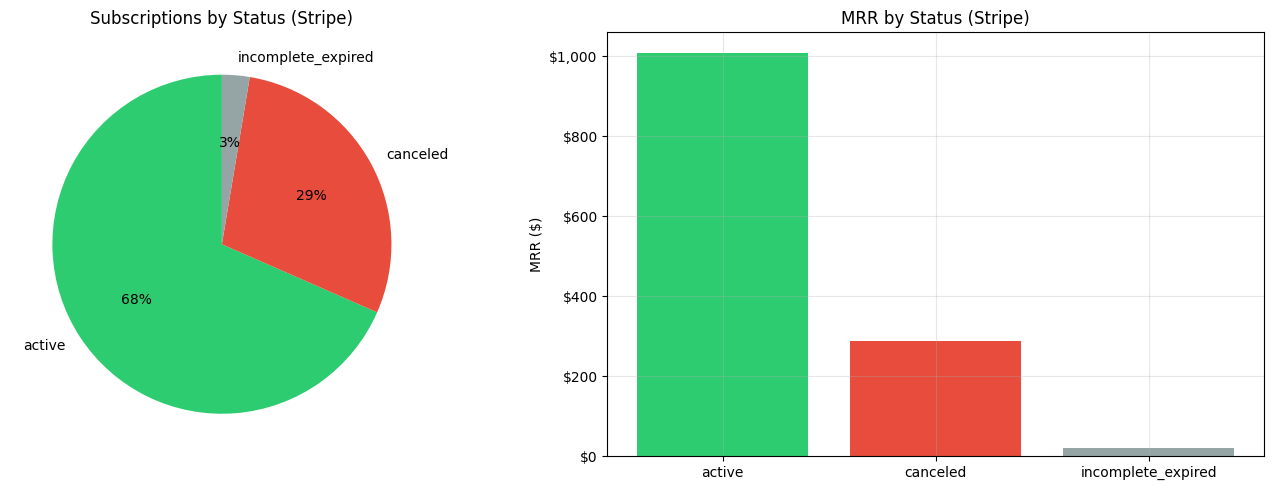

,status,count,mrr_cents,mrr
0,active,26,100933,"$1,009.33"
1,canceled,11,28900,$289.00
2,incomplete_expired,1,2100,$21.00


In [20]:
# Tidemill sources view
sources = api_get("/api/sources")
print("Connected sources:", [s["name"] for s in sources])
print()

# Stripe subscription status breakdown with MRR
status_summary = (
    df_stripe.groupby("status")
    .agg(
        count=("id", "count"),
        mrr_cents=("mrr_cents", "sum"),
    )
    .reset_index()
)
status_summary["mrr"] = status_summary.mrr_cents.apply(lambda c: f"${c / 100:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: subscription count by status
status_colors = {
    "active": "#2ecc71",
    "canceled": "#e74c3c",
    "trialing": "#f39c12",
    "past_due": "#e67e22",
}
axes[0].pie(
    status_summary["count"],
    labels=status_summary.status,
    autopct="%1.0f%%",
    colors=[status_colors.get(s, "#95a5a6") for s in status_summary.status],
    startangle=90,
)
axes[0].set_title("Subscriptions by Status (Stripe)")

# Bar: MRR by status
axes[1].bar(
    status_summary.status,
    status_summary.mrr_cents / 100,
    color=[status_colors.get(s, "#95a5a6") for s in status_summary.status],
)
axes[1].set_title("MRR by Status (Stripe)")
axes[1].set_ylabel("MRR ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

status_summary